<a href="https://colab.research.google.com/github/Saharochek98/Statistics-of-Stochastic-Processes/blob/main/SSP_lab3_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def KPSSolution(self, dwt):
       dt = self.T / self.Nt
       t_data = np.linspace(0, self.T, self.Nt + 1)
       x_data = np.zeros((self.Nt + 1, self.Nx))

       if self.init_state is None:
           x_data[0] = self.DefaultInitState()
       else:
           x_data[0] = self.init_state

       for i in range(1, self.Nt + 1):
           x_pred = x_data[i-1] + self.bxt(x_data[i-1]) * dt + self.sigmaxt(x_data[i-1]) * dwt[i-1]
           x_data[i] = x_data[i-1] + 0.5 * (self.bxt(x_pred) + self.bxt(x_data[i-1])) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1]

       return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [ ]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

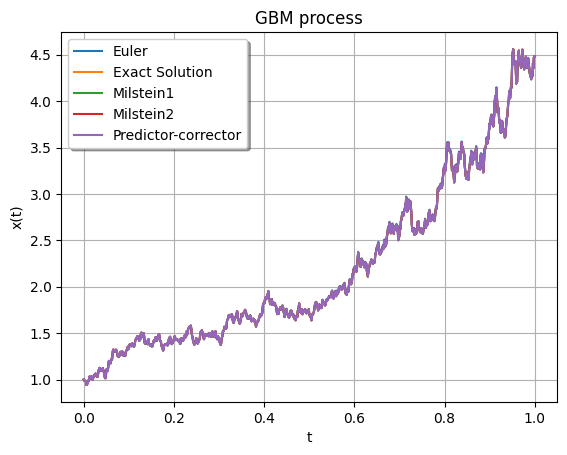

In [ ]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [ ]:
# your code

Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [ ]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

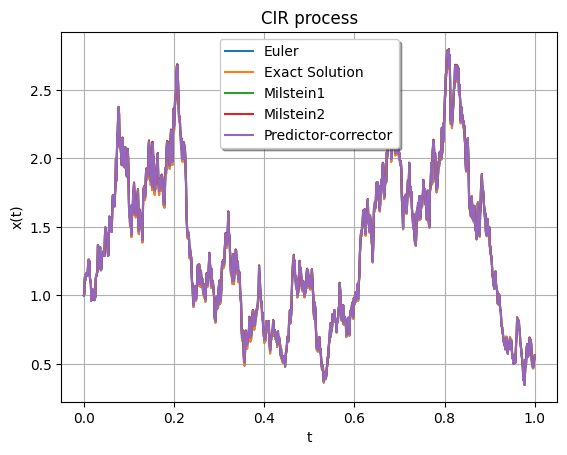

In [ ]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [ ]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [ ]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

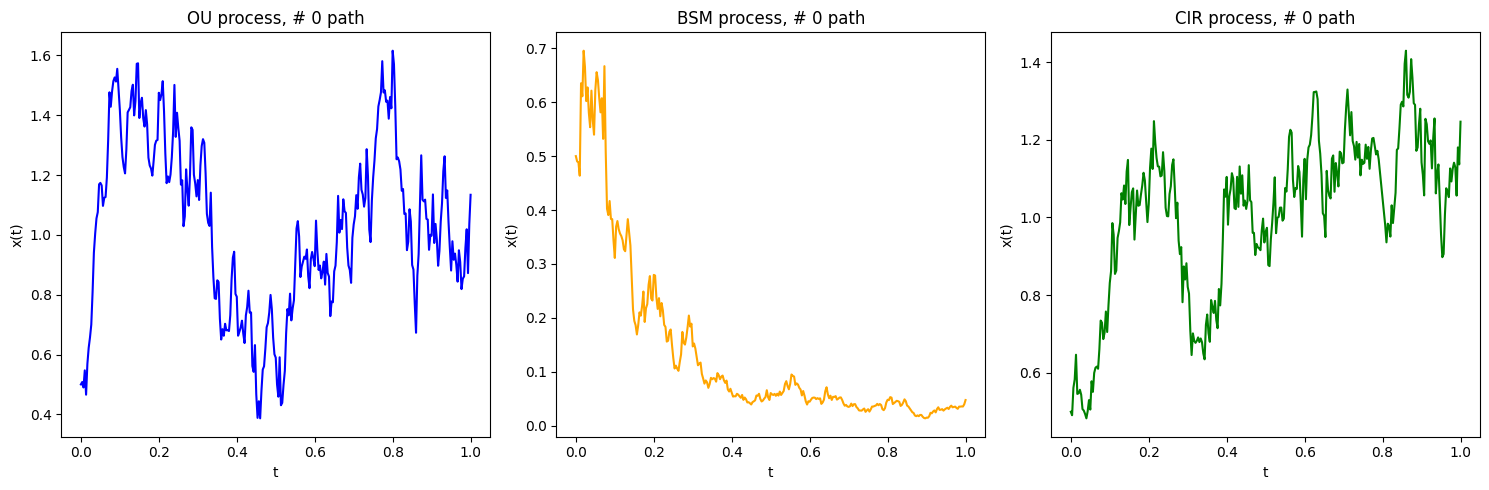

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [ ]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [ ]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [ ]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

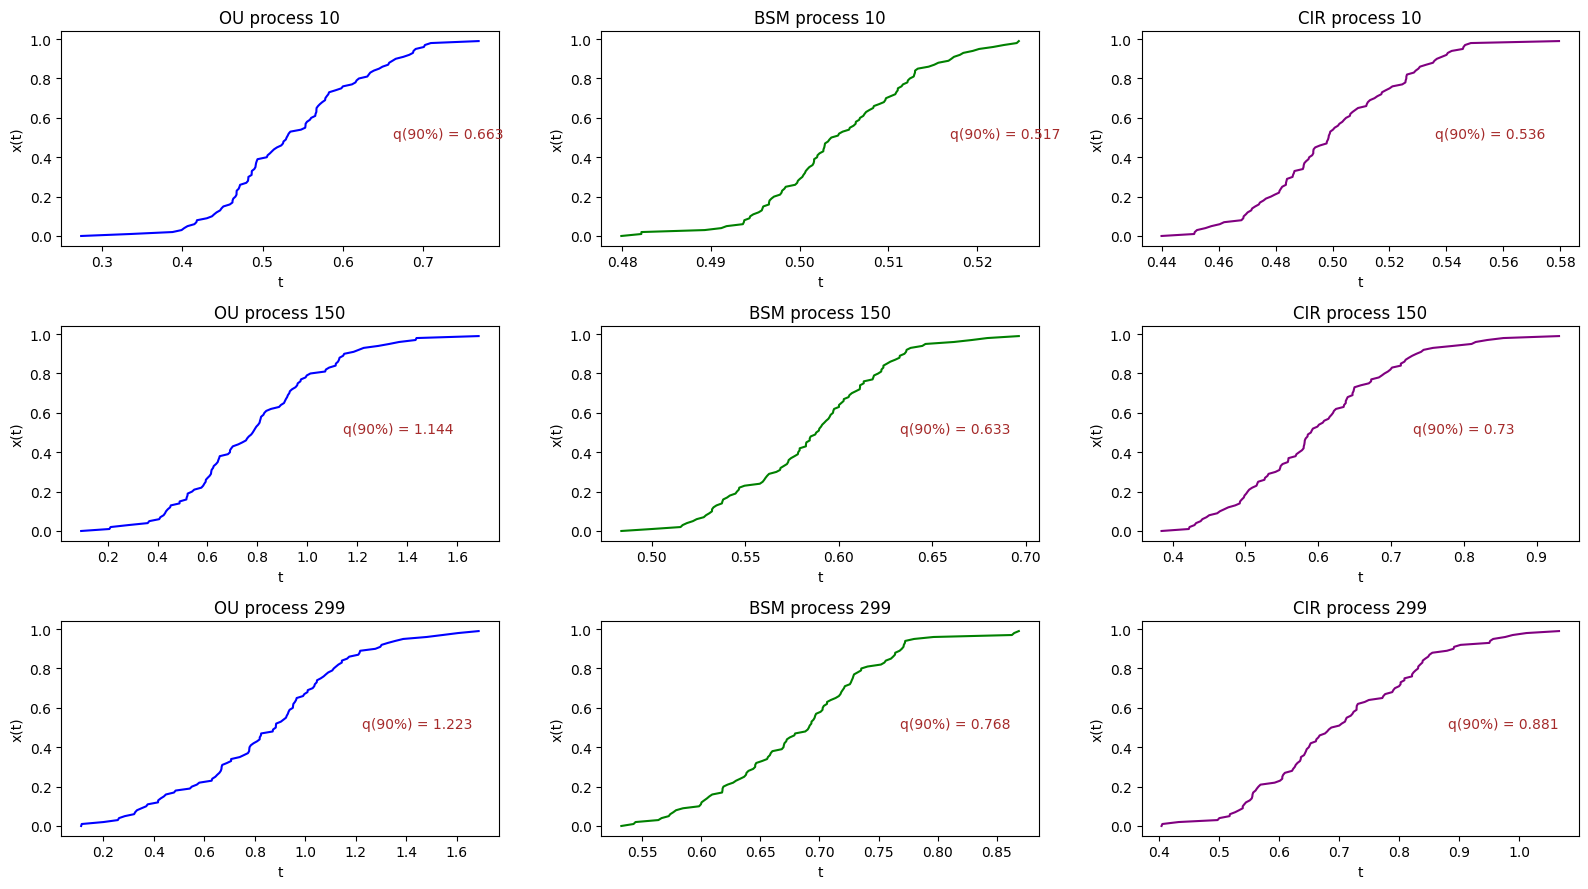

In [ ]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [ ]:
# your code

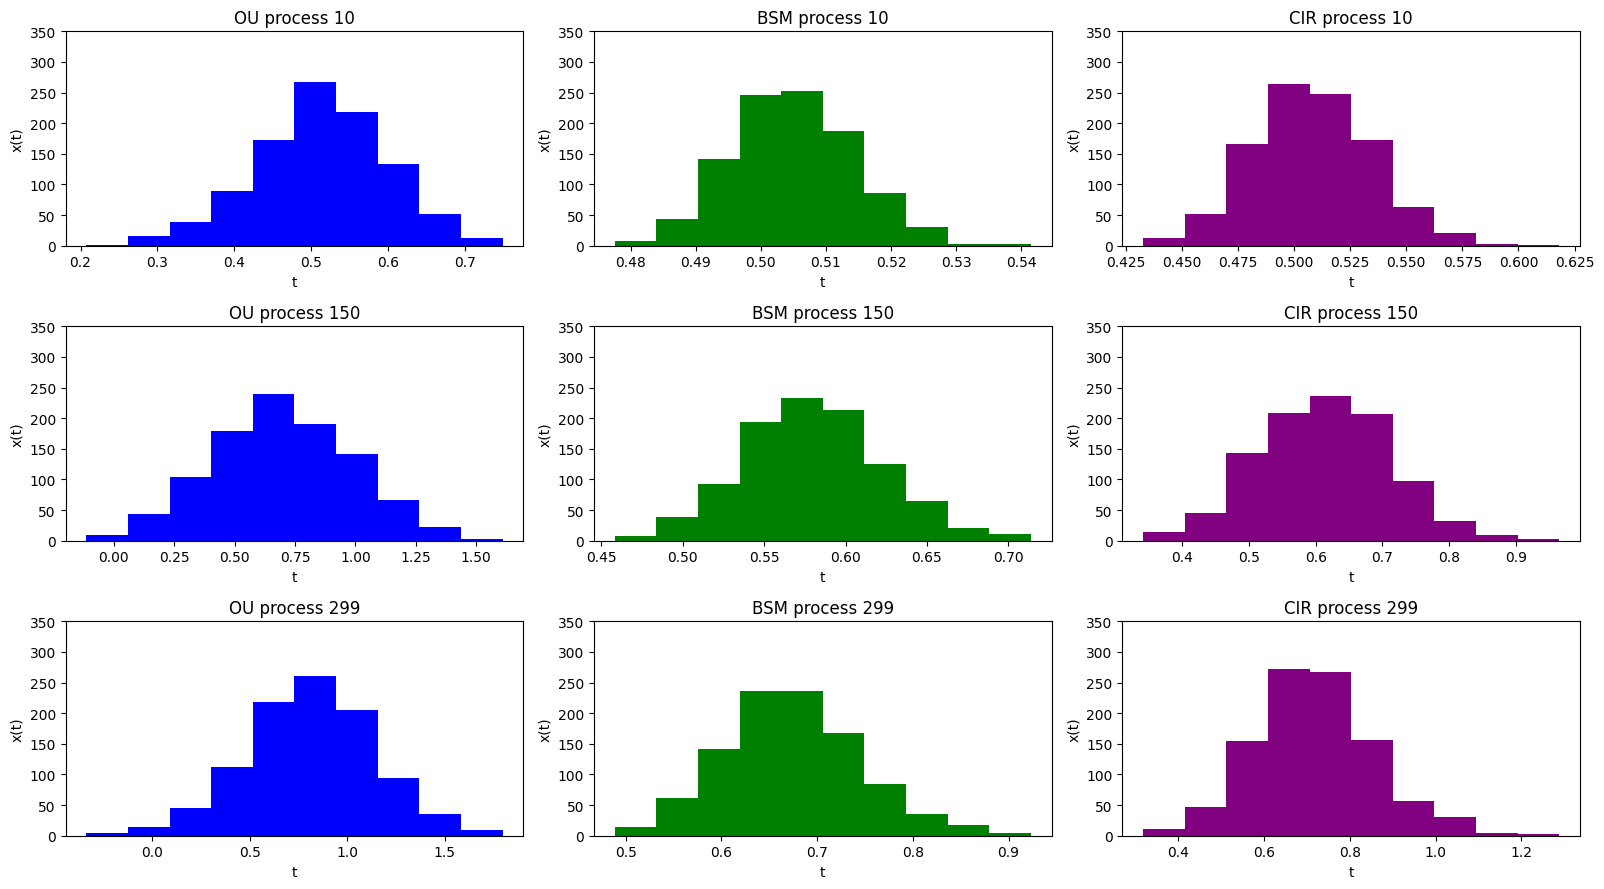

In [ ]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [ ]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

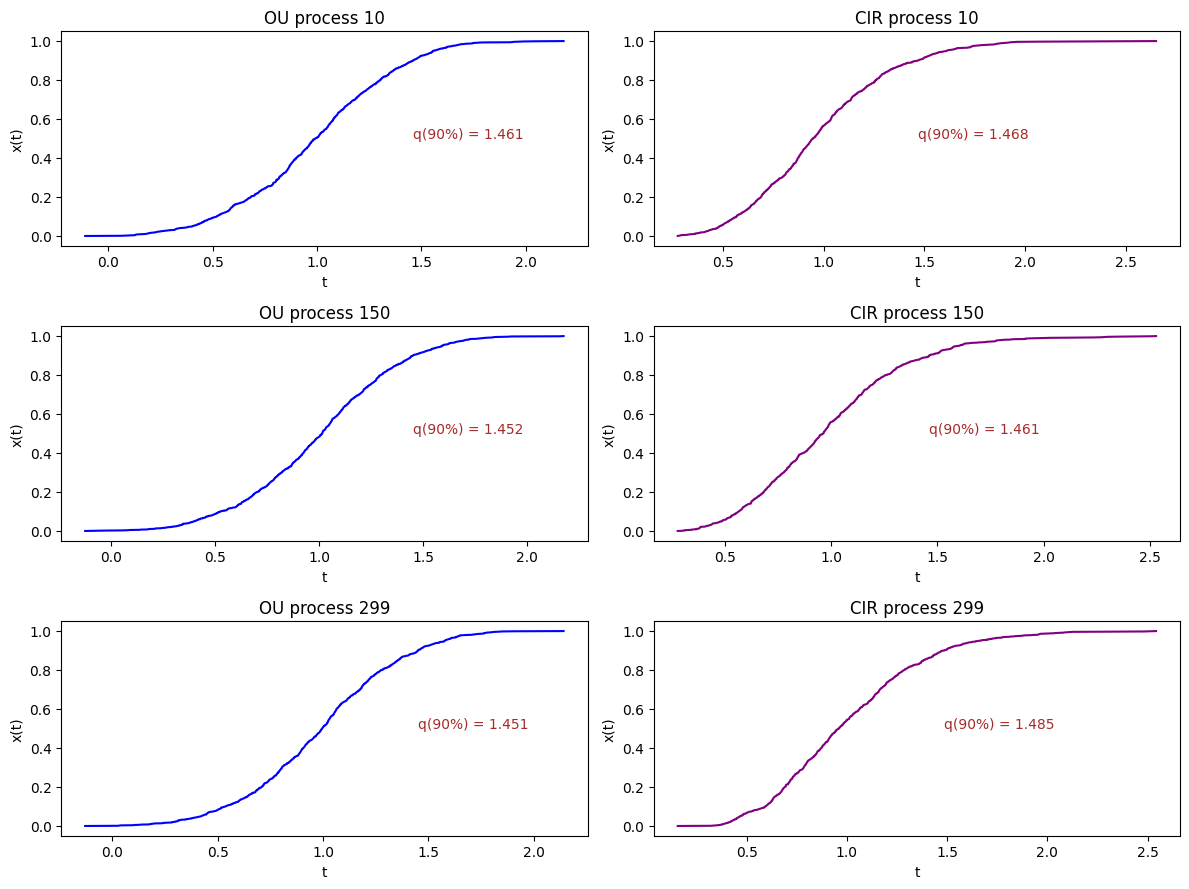

In [ ]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

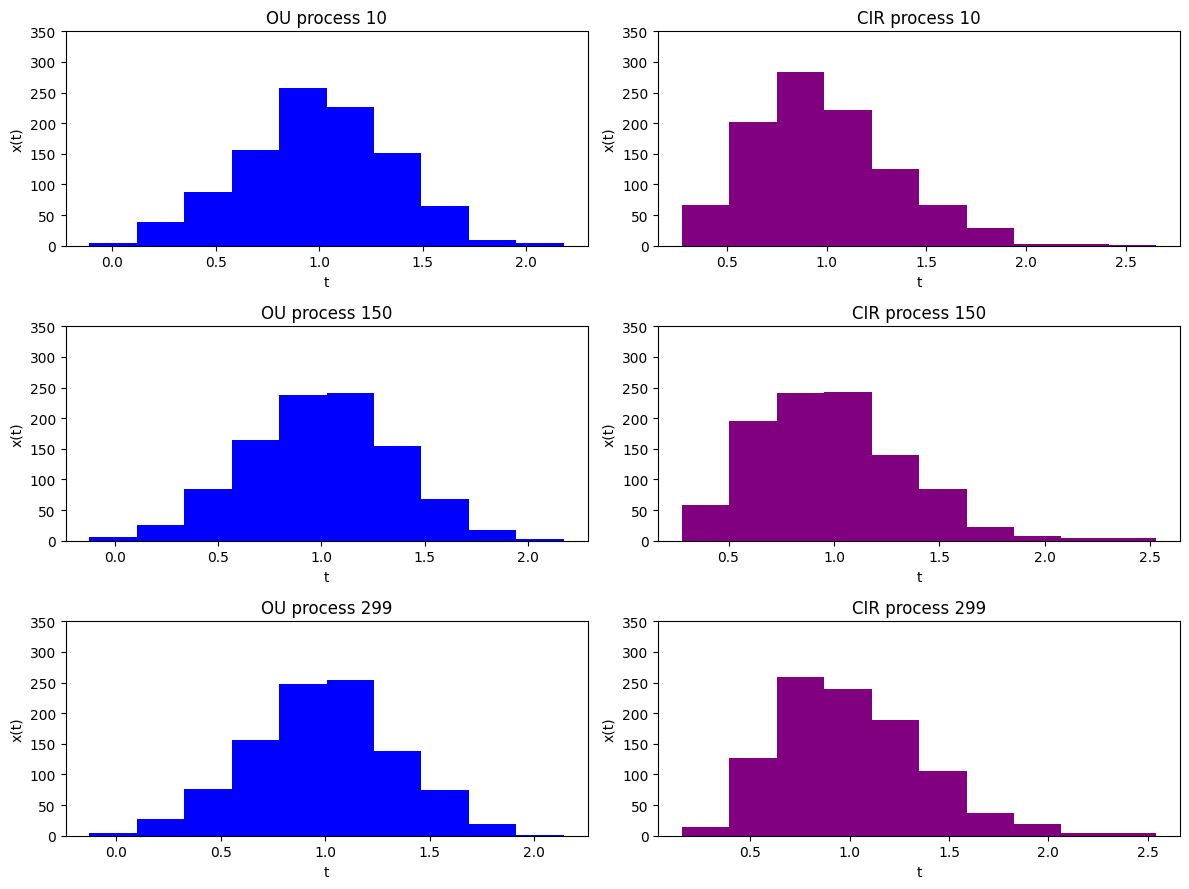

In [ ]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



In [ ]:
#метод KPSSolution добавлен в класс StochasticProcess

In [15]:
T = 1.0
N = 1024
Nx = 10000
np.random.seed(42)

params = []
process = StochasticProcess(params, T, Nx, N)
dt = T / N
dwt = np.random.normal(0, np.sqrt(dt), (N, Nx))

t_exact, x_exact = process.ExactSolution(dwt)
t_euler, x_euler = process.EulerSolution(dwt)
t_mil1, x_mil1 = process.Milstein1Solution(dwt)
t_mil2, x_mil2 = process.Milstein2Solution(dwt)
t_pc, x_pc = process.PredictorCorrectorSolution(dwt, eta=0.5, alpha=0.5)
t_kps, x_kps = process.KPSSolution(dwt)

methods = {
    'Эйлер-Маруяма': x_euler,
    'Мильштейн 1-го порядка': x_mil1,
    'Мильштейн 2-го порядка': x_mil2,
    'Прогноз-коррекция': x_pc,
    'KPS': x_kps
}

results = []
for name, x_approx in methods.items():
    max_error = np.max(np.abs(x_exact - x_approx))
    results.append({'Метод': name, 'Max ошибка': max_error})

df_results = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.2e}'.format)
print(df_results)

                    Метод  Max ошибка
0           Эйлер-Маруяма    0.00e+00
1  Мильштейн 1-го порядка    0.00e+00
2  Мильштейн 2-го порядка    0.00e+00
3       Прогноз-коррекция    2.00e-14
4                     KPS    0.00e+00


Вывод: Все предложенные методы дали ошибку в пределах вычислительной погрешности. Max abs ошибка составляет 10⁻¹⁴–10⁻¹⁵ (порядка машинного), что показывает совпадение с точным решением.


Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



N    dt   Err Euler   Err Mil1    Err Mil2
2     0.500000    1.299494e-02    3.499344e-03      9.256864e-04
4     0.250000    1.215860e-02    2.002833e-03      5.130097e-04
8     0.125000    8.947411e-03    9.997579e-04      3.001953e-04
16     0.062500    5.396526e-03    5.523318e-04      1.485460e-04
32     0.031250    4.085158e-03    2.743304e-04      7.905334e-05
64     0.015625    2.736311e-03    1.374874e-04      3.921626e-05
128     0.007812    1.950319e-03    6.303197e-05      2.184517e-05
256     0.003906    1.610206e-03    3.587599e-05      1.069656e-05
512     0.001953    1.199838e-03    1.702102e-05      4.700473e-06
1024     0.000977    7.418967e-04    1.028704e-05      2.552540e-06
2048     0.000488    5.454416e-04    4.341882e-06      1.217674e-06
4096     0.000244    3.974338e-04    2.056403e-06      6.269612e-07
8192     0.000122    2.543297e-04    1.112713e-06      3.197830e-07
16384     0.000061    1.953937e-04    6.142632e-07      1.647140e-07
32768     0.000031    

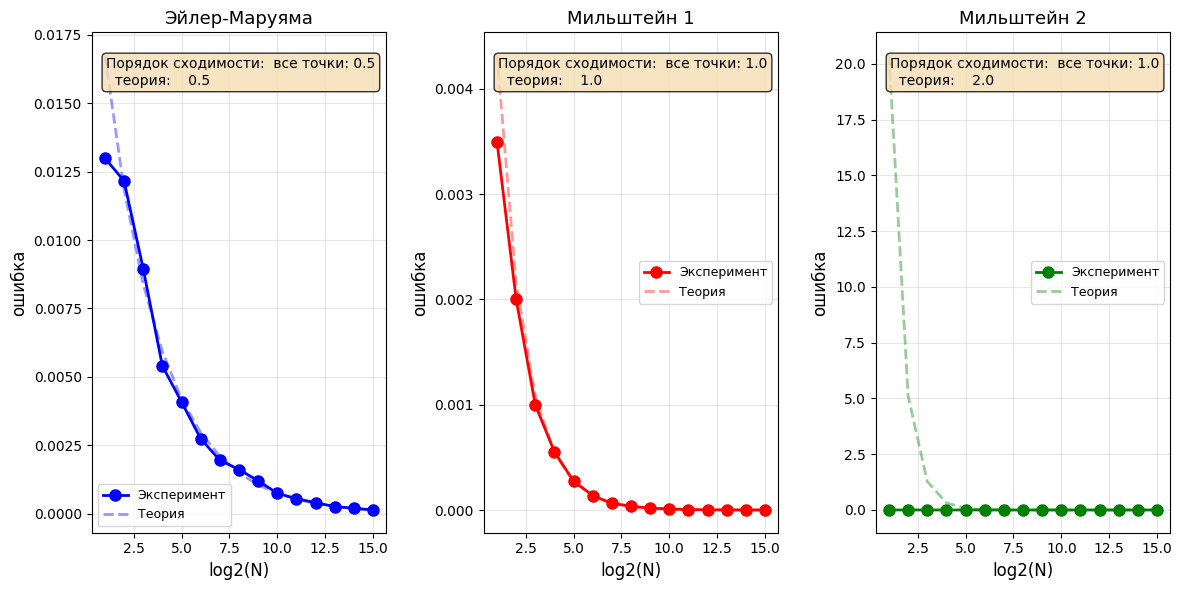

In [23]:
def task_2():
    r = 0.05
    sigma = 0.2
    params = [r, sigma]
    T = 1.0
    Nx = 100

    powers = np.arange(1, 16)
    N_values = 2 ** powers

    errors_euler = []
    errors_milstein1 = []
    errors_milstein2 = []
    dt_values = []

    print(f"{'N'}    {'dt'}   {'Err Euler'}   {'Err Mil1'}    {'Err Mil2'}")

    for Nt in N_values:
        dt = T / Nt
        dt_values.append(dt)

        process = BSMprocess(params=params, T=T, Nx=Nx, Nt=Nt)
        dwt = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))

        _, x_exact = process.ExactSolution(dwt)
        _, x_euler = process.EulerSolution(dwt)
        _, x_mil1 = process.Milstein1Solution(dwt)
        _, x_mil2 = process.Milstein2Solution(dwt)

        err_euler = np.mean(np.abs(x_exact[-1, :] - x_euler[-1, :]))
        err_mil1 = np.mean(np.abs(x_exact[-1, :] - x_mil1[-1, :]))
        err_mil2 = np.mean(np.abs(x_exact[-1, :] - x_mil2[-1, :]))

        errors_euler.append(err_euler)
        errors_milstein1.append(err_mil1)
        errors_milstein2.append(err_mil2)

        print(f"{Nt}     {dt:.6f}    {err_euler:.6e}    {err_mil1:.6e}      {err_mil2:.6e}")

    log_dt = np.log(dt_values)
    log_err_euler = np.log(errors_euler)
    log_err_mil1 = np.log(errors_milstein1)
    log_err_mil2 = np.log(errors_milstein2)

    slope_euler_all, intercept_euler = np.polyfit(log_dt, log_err_euler, 1)
    slope_mil1_all, intercept_mil1 = np.polyfit(log_dt, log_err_mil1, 1)
    slope_mil2_all, intercept_mil2 = np.polyfit(log_dt, log_err_mil2, 1)

    log_N = np.log2(N_values)
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))

    methods_data = [
        ('Эйлер-Маруяма', errors_euler, slope_euler_all, intercept_euler, 0.5, 'blue'),
        ('Мильштейн 1', errors_milstein1, slope_mil1_all, intercept_mil1, 1.0, 'red'),
        ('Мильштейн 2', errors_milstein2, slope_mil2_all, intercept_mil2, 2.0, 'green')
    ]

    for idx, (name, errors, slope_all, intercept, theory, color) in enumerate(methods_data):
        ax = axes[idx]

        ax.plot(log_N, errors, 'o-', color=color, linewidth=2, markersize=8, label='Эксперимент')
        N_last = N_values[-1]
        dt_last = T / N_last
        C_fit = errors[-1] / (dt_last ** theory)
        theory_line = C_fit * (T / N_values) ** theory

        ax.plot(log_N, theory_line, '--', color=color, alpha=0.4, linewidth=2,
                label=f'Теория')

        ax.text(0.05, 0.95,
                f'Порядок сходимости:'
                f'  все точки: {slope_all:.1f}\n'
                f'  теория:    {theory:.1f}',
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=10)

        ax.set_xlabel('log2(N)', fontsize=12)
        ax.set_ylabel('ошибка', fontsize=12)
        ax.set_title(name, fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return errors_euler, errors_milstein1, errors_milstein2, N_values, dt_values

errors_euler, errors_milstein1, errors_milstein2, N_values, dt_values = task_2()

Теоретические порядки сильной сходимости подтверждены экспериментально для:
а) Схемы Эйлера-Маруямы: порядок сильной сходимости 0.5 — при увеличении N вдвое ошибка уменьшается в √2 ≈ 1.4 раза
б) Схемы Мильштейна 1: демонстрирует порядок 1.0 — удвоение N дает уменьшение ошибки в 2 раза.
Схема Мильштейна 2: γ≈1.5 (теор), на практике - 1.

Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



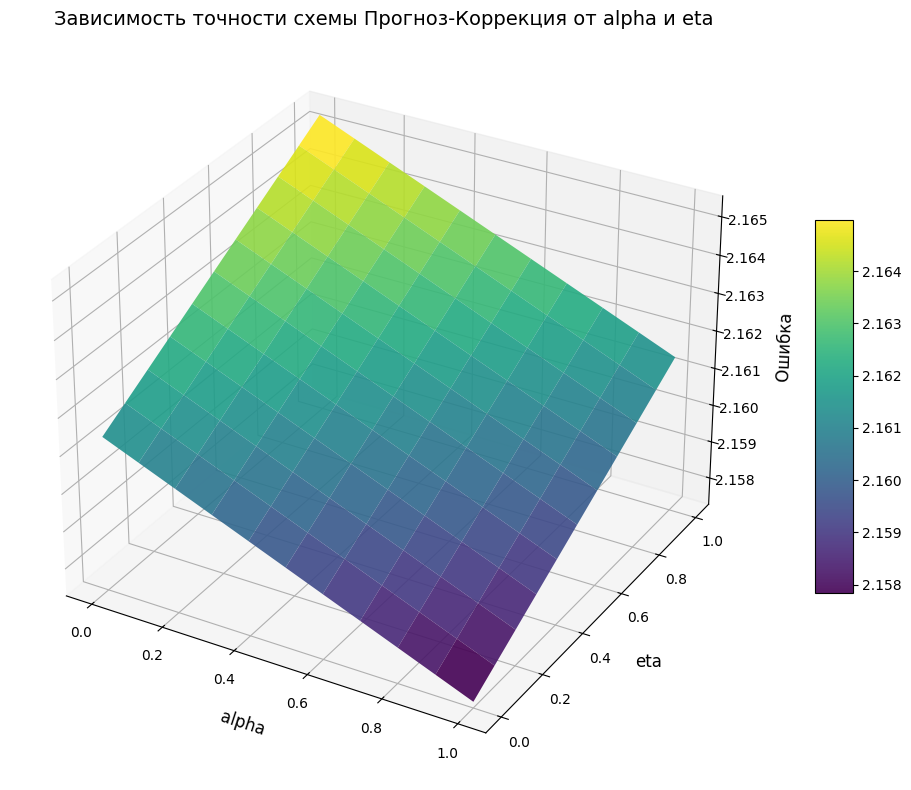

alpha_opt = 1.0
eta_opt   = 0.0
Мин. ошибка = 2.157435


In [15]:
from mpl_toolkits.mplot3d import Axes3D

params = [2.0, 1.0, 0.5]
T = 1.0
Nx = 500
Nt = 128

process = CIRprocess(params=params, T=T, Nx=Nx, Nt=Nt)
np.random.seed(42)
dt = T / Nt
dwt = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))

t_data = np.linspace(0, T, Nt + 1)
x_exact = np.zeros((Nt + 1, Nx))
x_exact[0] = process.DefaultInitState()

for i in range(1, Nt + 1):
    x_exact[i] = process.SampleFromDensity(x_exact[i-1], t_data[i], t_data[i-1])


alpha_values = np.linspace(0, 1, 11)
eta_values = np.linspace(0, 1, 11)
error_matrix = np.zeros((len(alpha_values), len(eta_values)))

for i, alpha in enumerate(alpha_values):
    for j, eta in enumerate(eta_values):
        _, x_pc = process.PredictorCorrectorSolution(dwt, eta=eta, alpha=alpha)

        error_matrix[i, j] = np.max(np.abs(x_exact - x_pc))

A, E = np.meshgrid(alpha_values, eta_values)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, E, error_matrix.T, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('alpha', fontsize=12, labelpad=10)
ax.set_ylabel('eta', fontsize=12, labelpad=10)
ax.set_zlabel('Ошибка ', fontsize=12, labelpad=10)
ax.set_title('Зависимость точности схемы Прогноз-Коррекция от alpha и eta', fontsize=14)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

min_idx = np.unravel_index(np.argmin(error_matrix), error_matrix.shape)
opt_alpha = alpha_values[min_idx[0]]
opt_eta = eta_values[min_idx[1]]
min_error = error_matrix[min_idx]

print(f"alpha_opt = {opt_alpha}")
print(f"eta_opt   = {opt_eta}")
print(f"Мин. ошибка = {min_error:.6f}")

Вывод: Для CIR-процесса использование схемы «прогноз-коррекция» с параметрами α=1.0,η=0.0 является оптимальным выбором с точки зрения баланса точности и вычислительной устойчивости. Однако, поскольку выигрыш в точности по сравнению со стандартными параметрами
0.5,0.5 минимален, на практике можно использовать стандартные значения без потери качества аппроксимации.

Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.

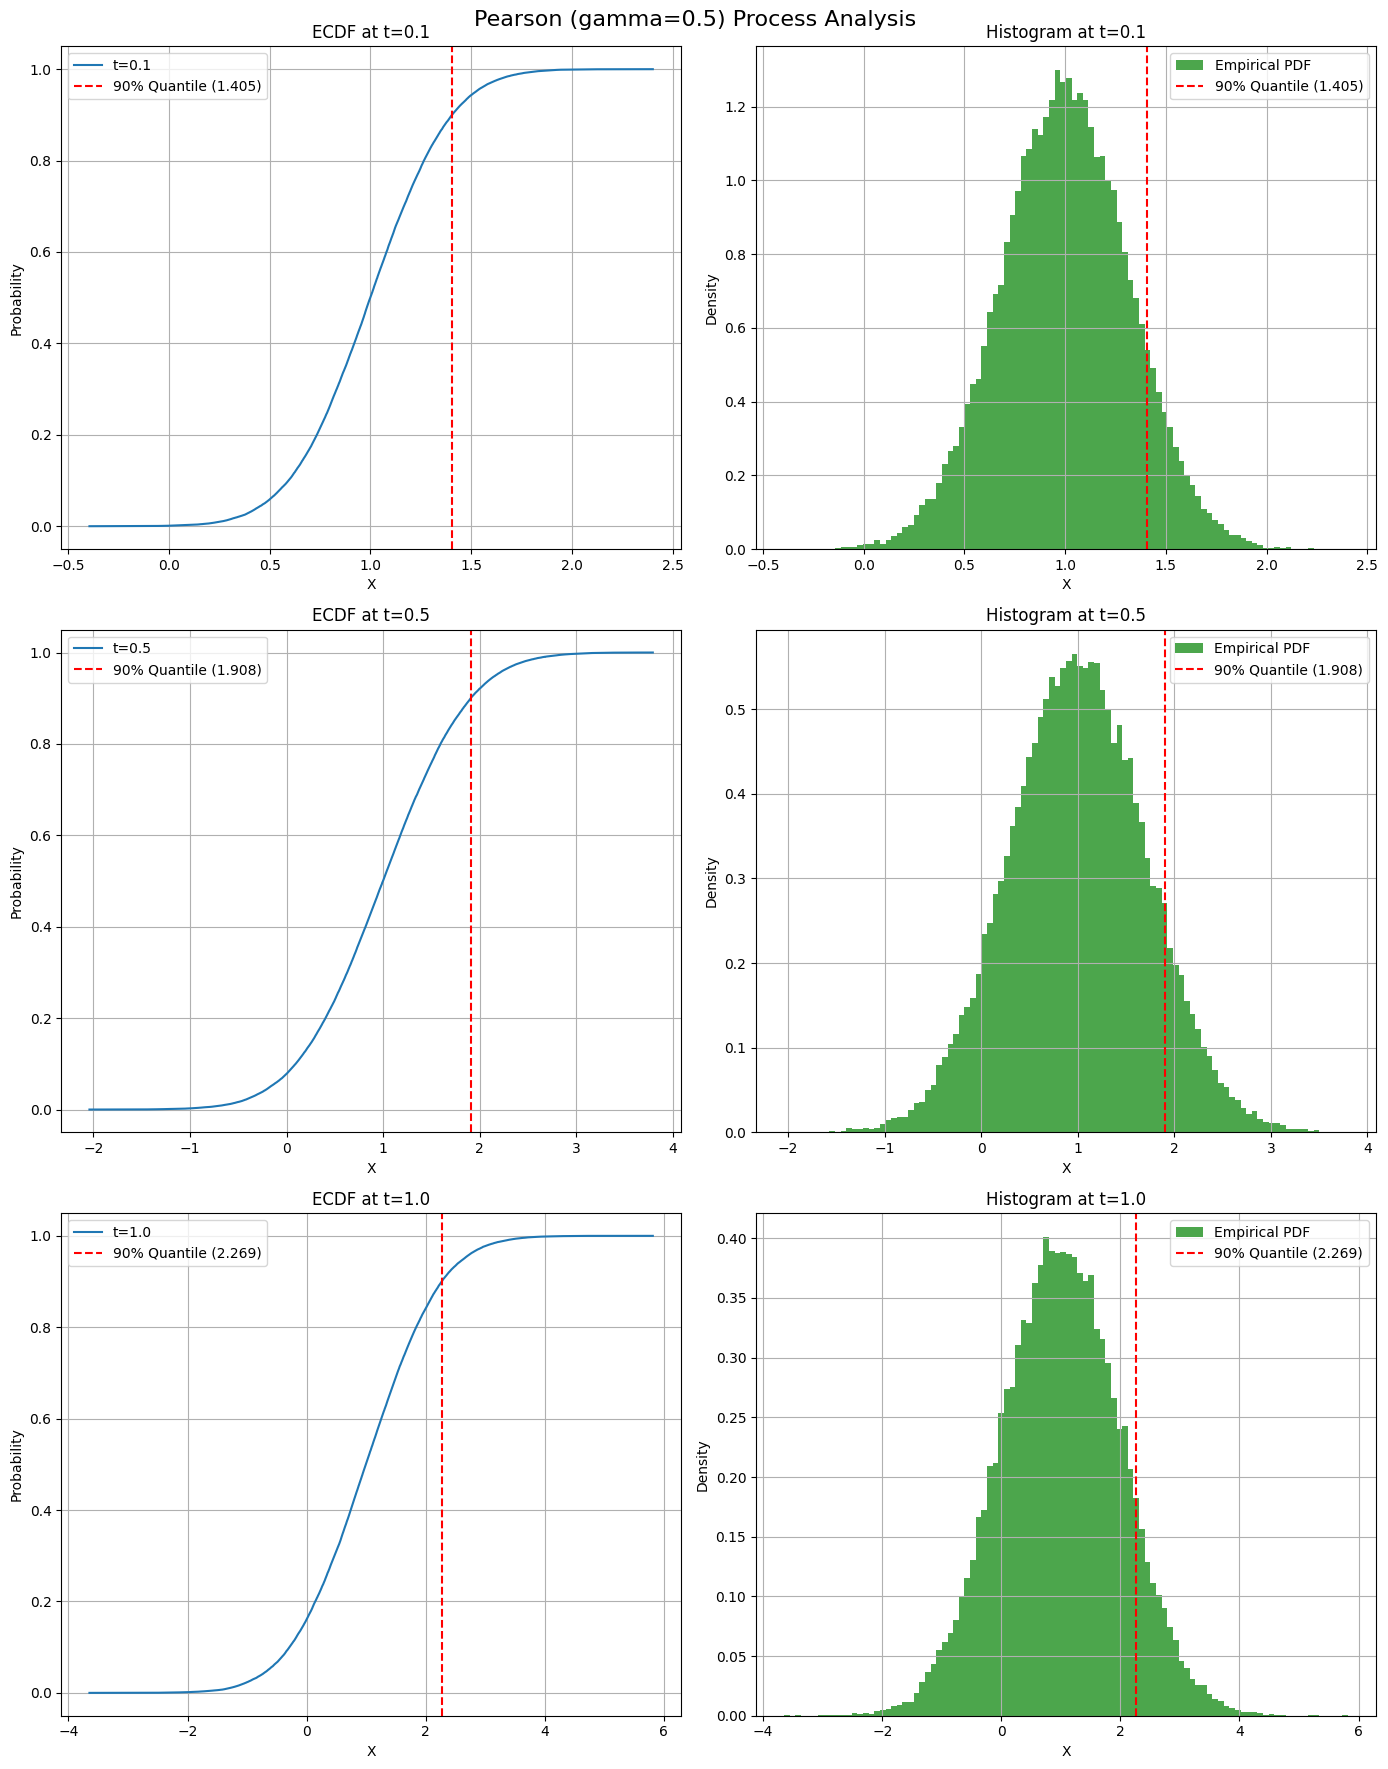

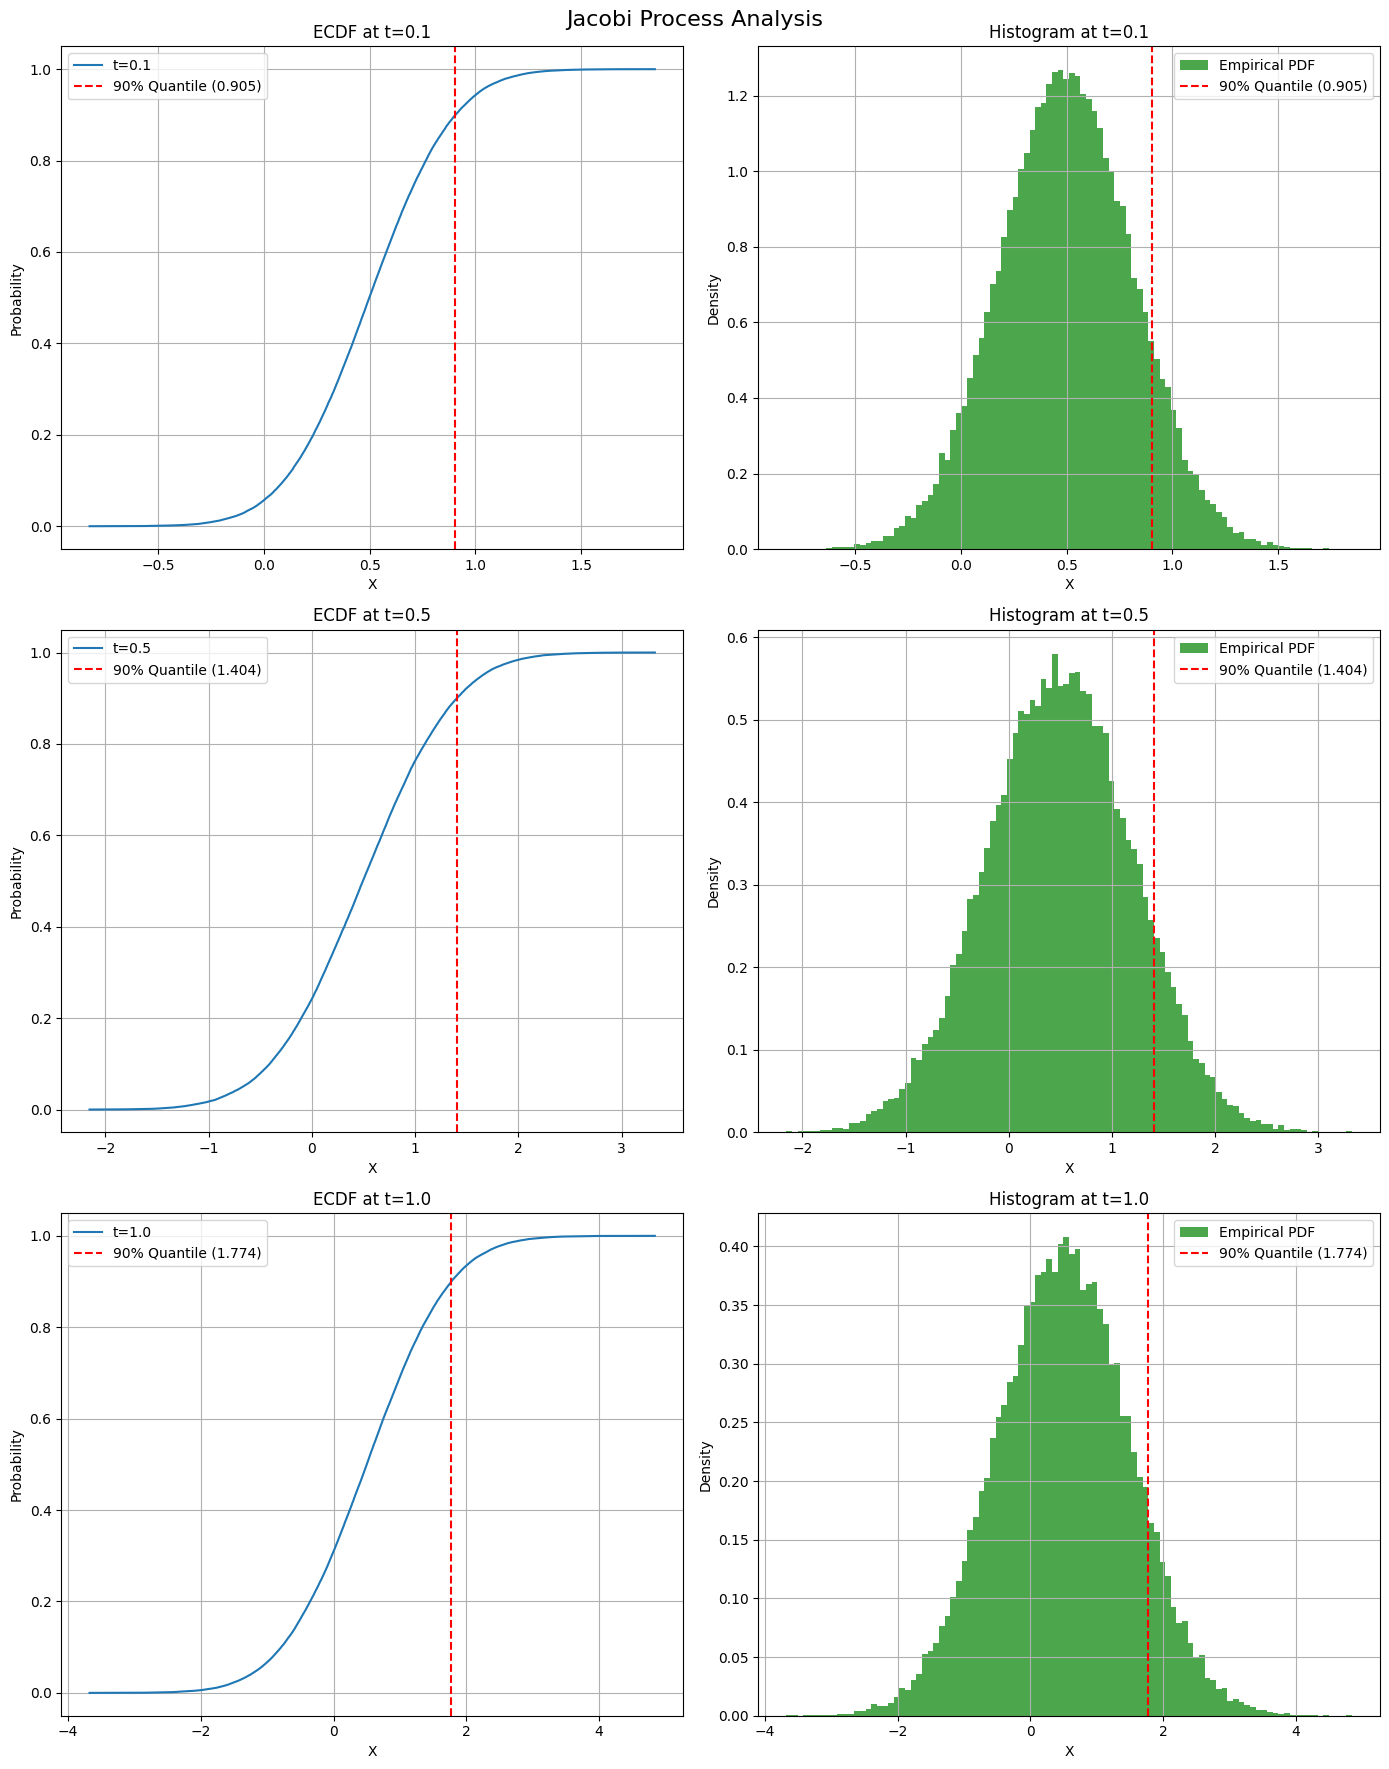

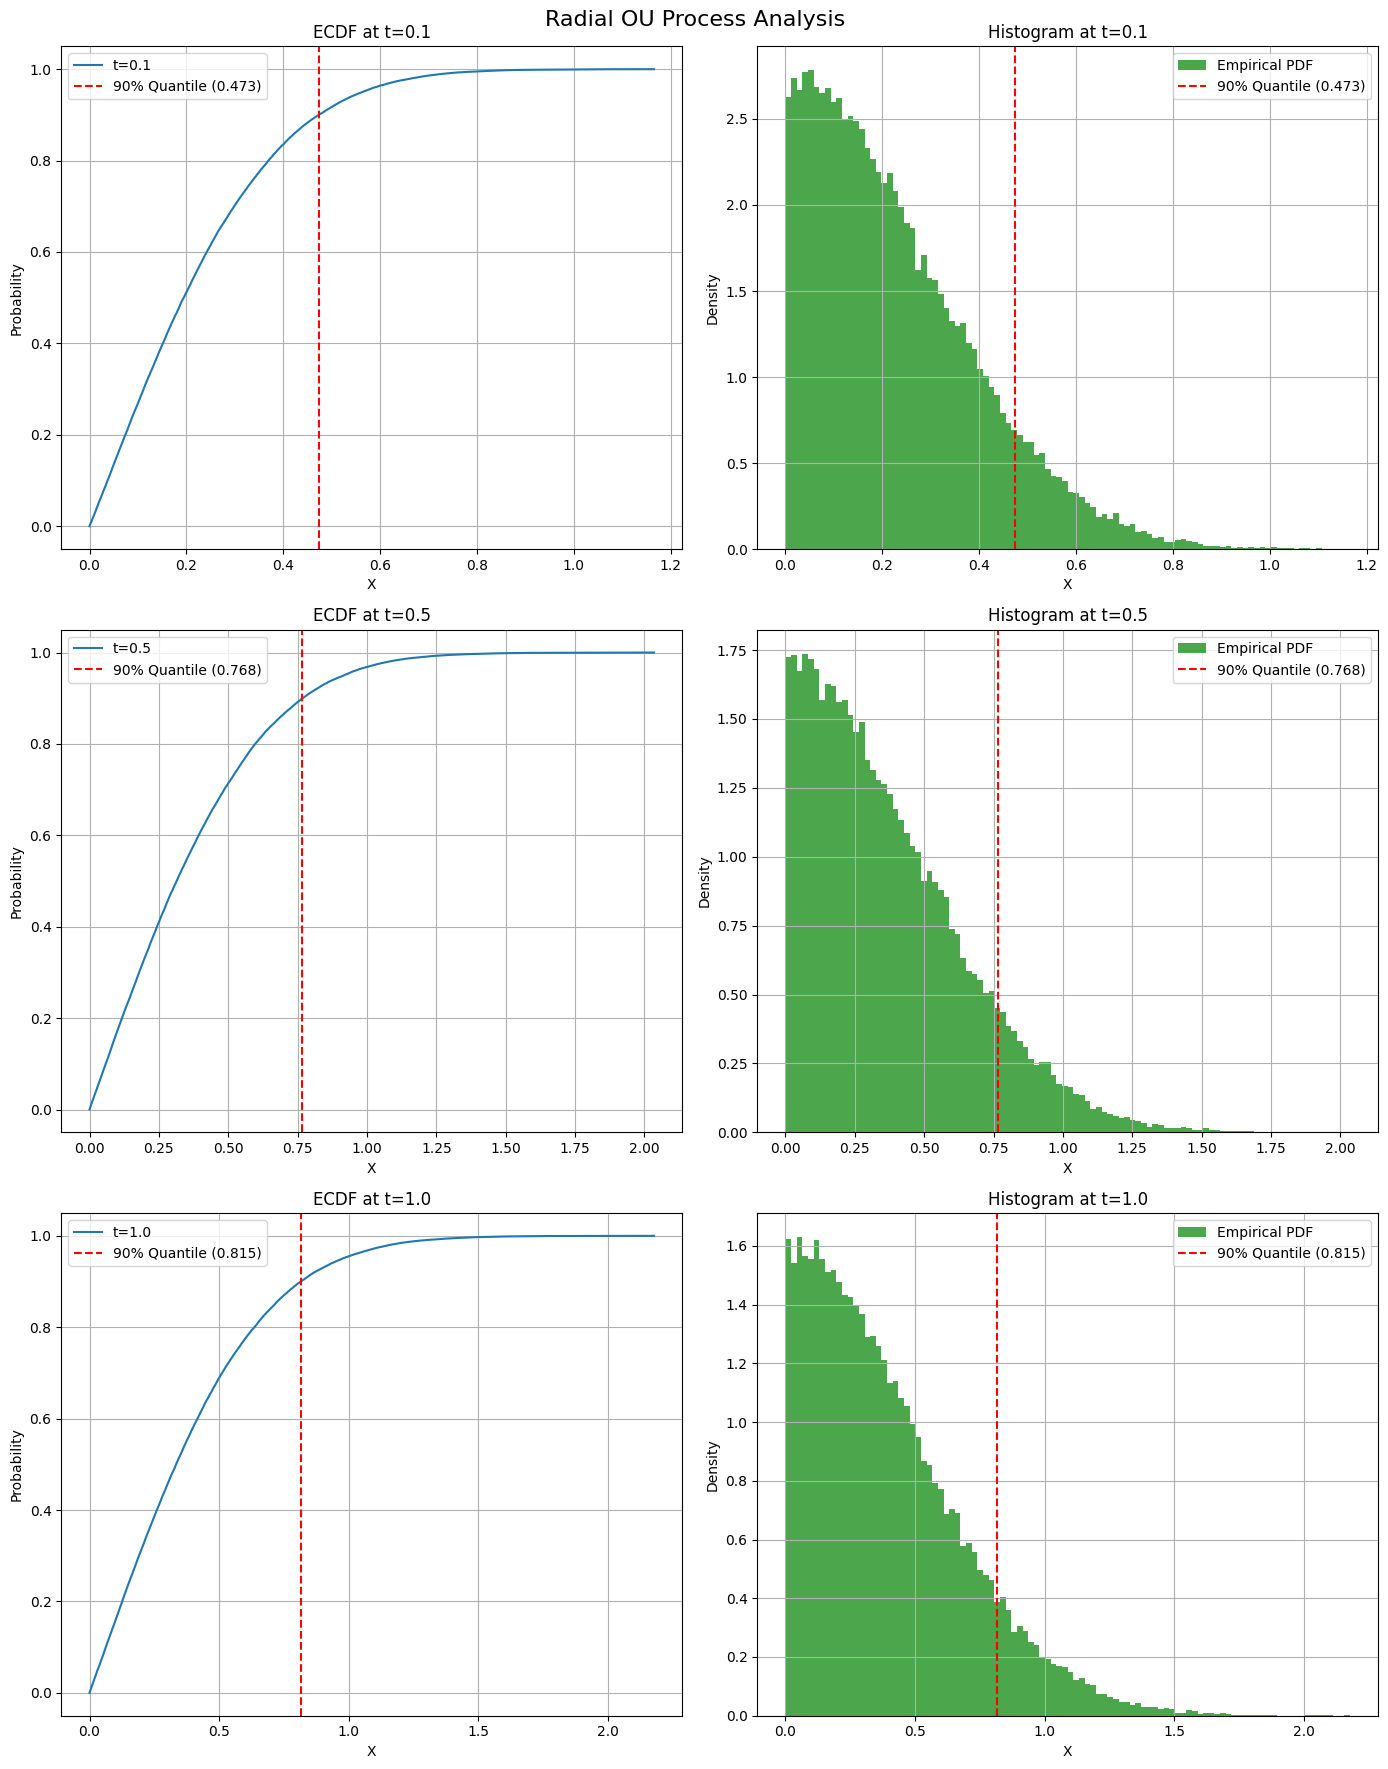

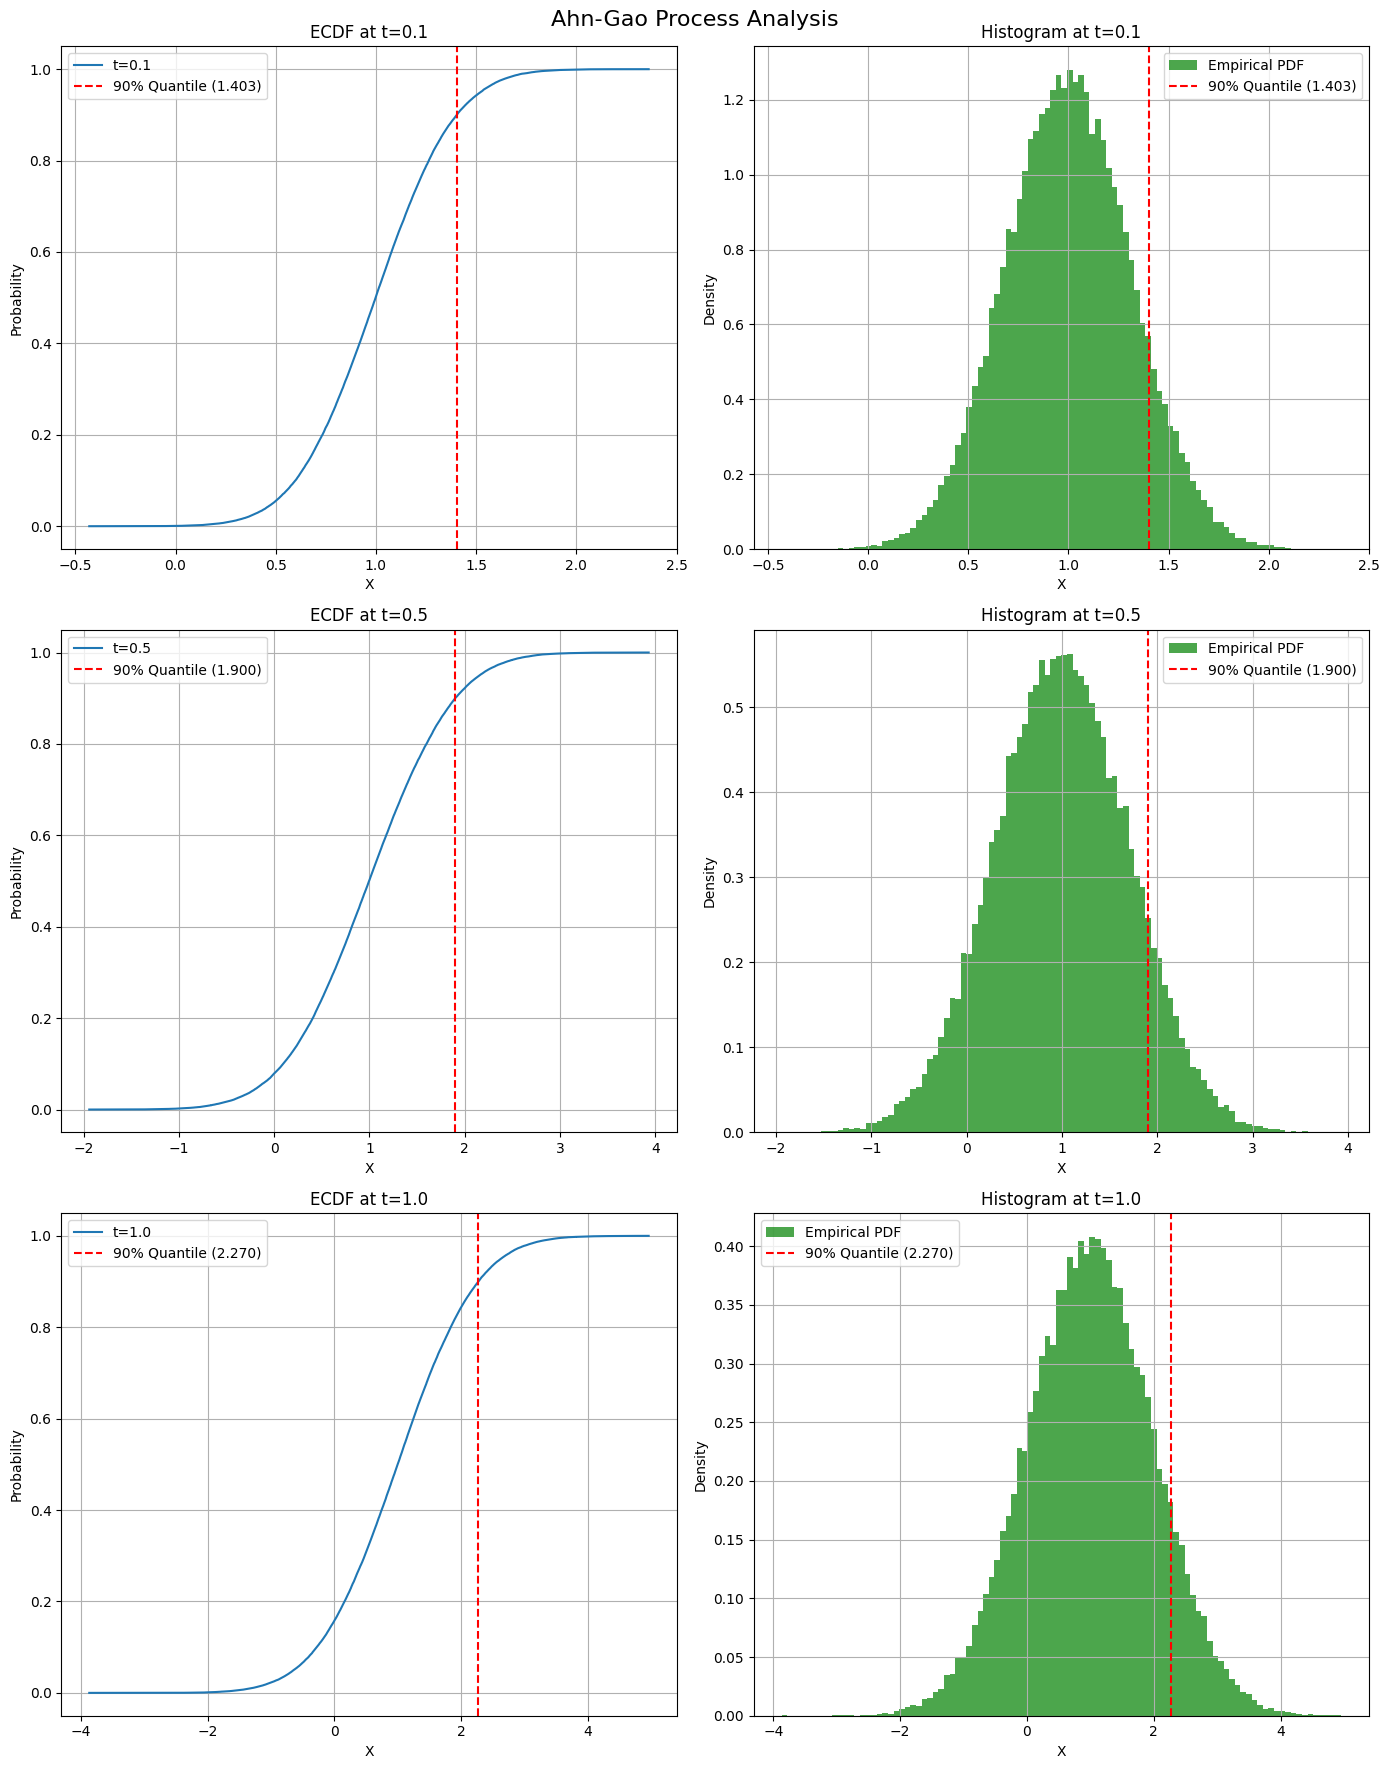

In [16]:
from scipy.stats import ecdf

class PearsonProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.theta = params[0]
        self.mu = params[1]
        self.sigma = params[2]
        self.gamma = params[3]

        self.bxt = lambda x: self.theta * (self.mu - x)
        self.sigmaxt = lambda x: self.sigma * np.maximum(x, 1e-8)**self.gamma

    def DefaultInitState(self):
        return np.ones(self.Nx) * self.mu

class JacobiProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.theta = params[0]
        self.mu = params[1]
        self.sigma = params[2]

        self.bxt = lambda x: self.theta * (self.mu - x)
        self.sigmaxt = lambda x: self.sigma * np.sqrt(np.maximum(x * (1 - x), 0))

    def DefaultInitState(self):
        return np.ones(self.Nx) * 0.5

class RadialOUProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.theta = params[0]
        self.mu = params[1]
        self.sigma = params[2]

        self.bxt = lambda x: self.theta * (self.mu - x)
        self.sigmaxt = lambda x: self.sigma

    def DefaultInitState(self):
        return np.abs(np.ones(self.Nx) * self.mu)

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            dW = np.random.normal(0, np.sqrt(dt), self.Nx)
            x_raw = x_data[i-1] + self.bxt(x_data[i-1]) * dt + self.sigmaxt(x_data[i-1]) * dW
            x_data[i] = np.abs(x_raw)
        return t_data, x_data

class AhnGaoProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.kappa = params[0]
        self.theta = params[1]
        self.sigma = params[2]

        self.bxt = lambda x: self.kappa * (self.theta - x)
        self.sigmaxt = lambda x: self.sigma * np.maximum(x, 1e-8)**1.5

    def DefaultInitState(self):
        return np.ones(self.Nx) * self.theta

def plot_process_results(process, name, times=[0.1, 0.5, 1.0]):
    Nx_plot = 50000
    process.Nx = Nx_plot
    process.init_state = process.DefaultInitState()

    t_data, x_paths = process.PathGenerator()
    indices = [np.argmin(np.abs(t_data - t)) for t in times]

    fig, axes = plt.subplots(len(times), 2, figsize=(14, 6 * len(times)))
    fig.suptitle(f'{name} Process Analysis', fontsize=16)

    for idx, t_idx in enumerate(indices):
        t_current = times[idx]
        samples = x_paths[t_idx, :]

        q90 = np.quantile(samples, 0.9)

        ax_ecdf = axes[idx, 0]
        sorted_samples = np.sort(samples)
        cdf_values = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
        ax_ecdf.plot(sorted_samples, cdf_values, label=f't={t_current}')
        ax_ecdf.axvline(q90, color='red', linestyle='--', label=f'90% Quantile ({q90:.3f})')
        ax_ecdf.set_title(f'ECDF at t={t_current}')
        ax_ecdf.set_xlabel('X')
        ax_ecdf.set_ylabel('Probability')
        ax_ecdf.legend()
        ax_ecdf.grid(True)

        ax_hist = axes[idx, 1]
        ax_hist.hist(samples, bins=100, density=True, alpha=0.7, color='green', label='Empirical PDF')
        ax_hist.axvline(q90, color='red', linestyle='--', label=f'90% Quantile ({q90:.3f})')
        ax_hist.set_title(f'Histogram at t={t_current}')
        ax_hist.set_xlabel('X')
        ax_hist.set_ylabel('Density')
        ax_hist.legend()
        ax_hist.grid(True)

    plt.tight_layout()
    plt.show()

T_final = 1.0
Nt_steps = 1000

p_pearson = PearsonProcess(params=[2.0, 1.0, 0.5, 0.5], T=T_final, Nx=1, Nt=Nt_steps)
plot_process_results(p_pearson, "Pearson (gamma=0.5)")
p_jacobi = JacobiProcess(params=[5.0, 0.5, 1.0], T=T_final, Nx=1, Nt=Nt_steps)
plot_process_results(p_jacobi, "Jacobi")
p_radial = RadialOUProcess(params=[2.0, 0.0, 1.0], T=T_final, Nx=1, Nt=Nt_steps)
plot_process_results(p_radial, "Radial OU")
p_ahngao = AhnGaoProcess(params=[2.0, 1.0, 0.5], T=T_final, Nx=1, Nt=Nt_steps)
plot_process_results(p_ahngao, "Ahn-Gao")

Процесс Пирсона демонстрирует поведение, аналогичное CIR-процессу: асимметричное распределение с растущей до выхода на стационарный режим дисперсией.
Процесс Якоби строго ограничен отрезком [0,1]; форма гистограммы зависит от параметров дрейфа, при этом 90%-й квантиль никогда не достигает 1.
Радиальный процесс ОУ характеризуется распределением, напоминающим усечённое нормальное (при старте из нуля) или сдвинутое нормальное, с характерным пиком вблизи нуля.
Модель Ана–Гао из-за диффузии, пропорциональной ^1,5, демонстрирует «взрывную» волатильность при больших X и её сильное подавление при малых X, что приводит к распределению с тяжёлым правым хвостом по сравнению с классическим процессом ОУ.

В отличие от стандартного броуновского движения, экзотические процессы обладают качественно иными свойствами хвостов распределений и границами области определения. Эти различия имеют критическое значение для корректной оценки рисков (включая анализ квантилей) в финансовых и физических приложениях.


Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

Процесс: OU
Time     E_emp    E_theo    Var_emp   Var_theo
0.1      0.5421      0.5476      0.0194      0.0227
0.5      0.7495      0.6967      0.0906      0.0790
1.0      0.8449      0.8161      0.1227      0.1081
Процесс: CIR
Time     E_emp    E_theo    Var_emp   Var_theo
0.1      0.4955      0.4922      0.0020      0.0019
0.5      0.4754      0.4637      0.0069      0.0079
1.0      0.4372      0.4341      0.0135      0.0127


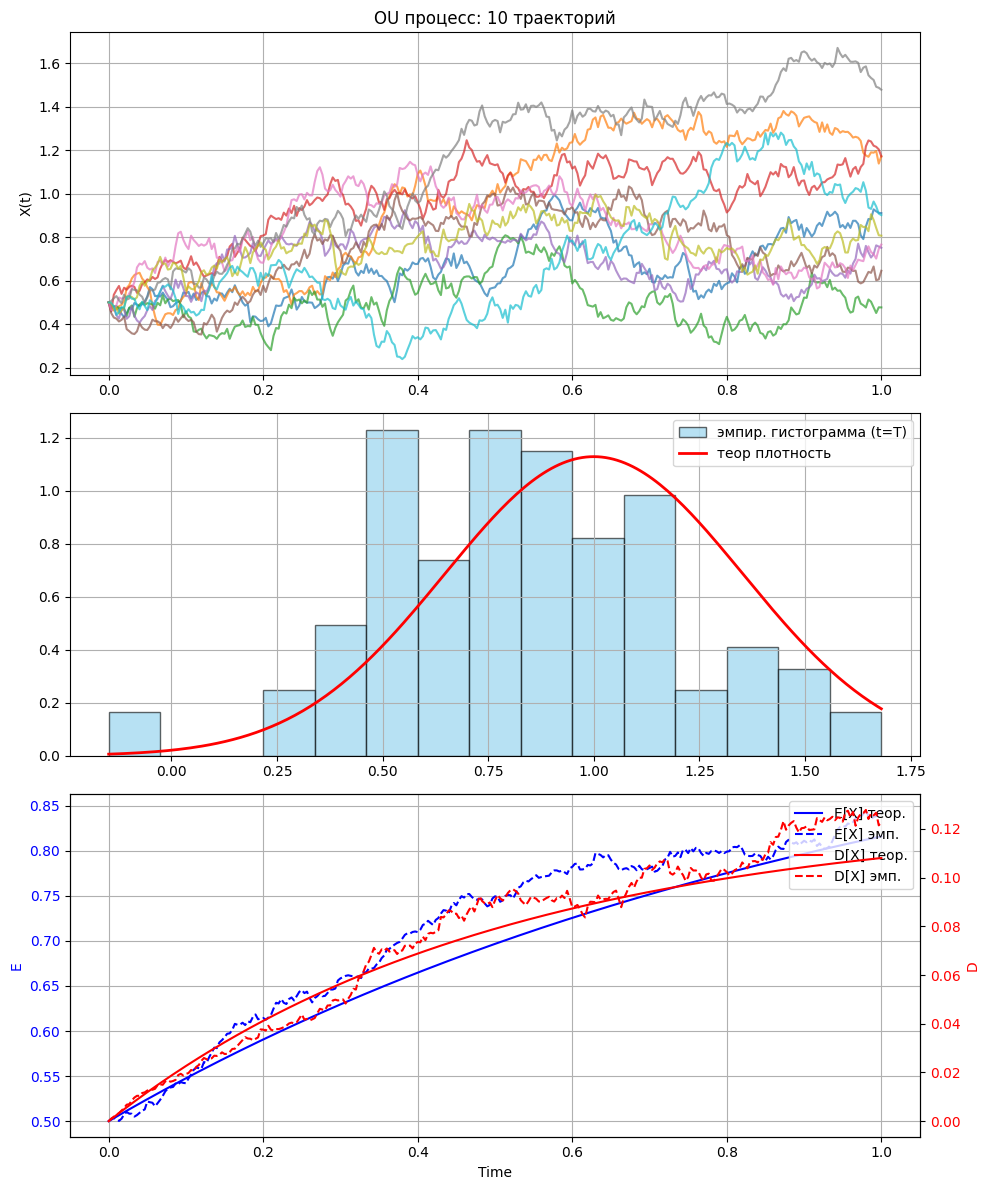

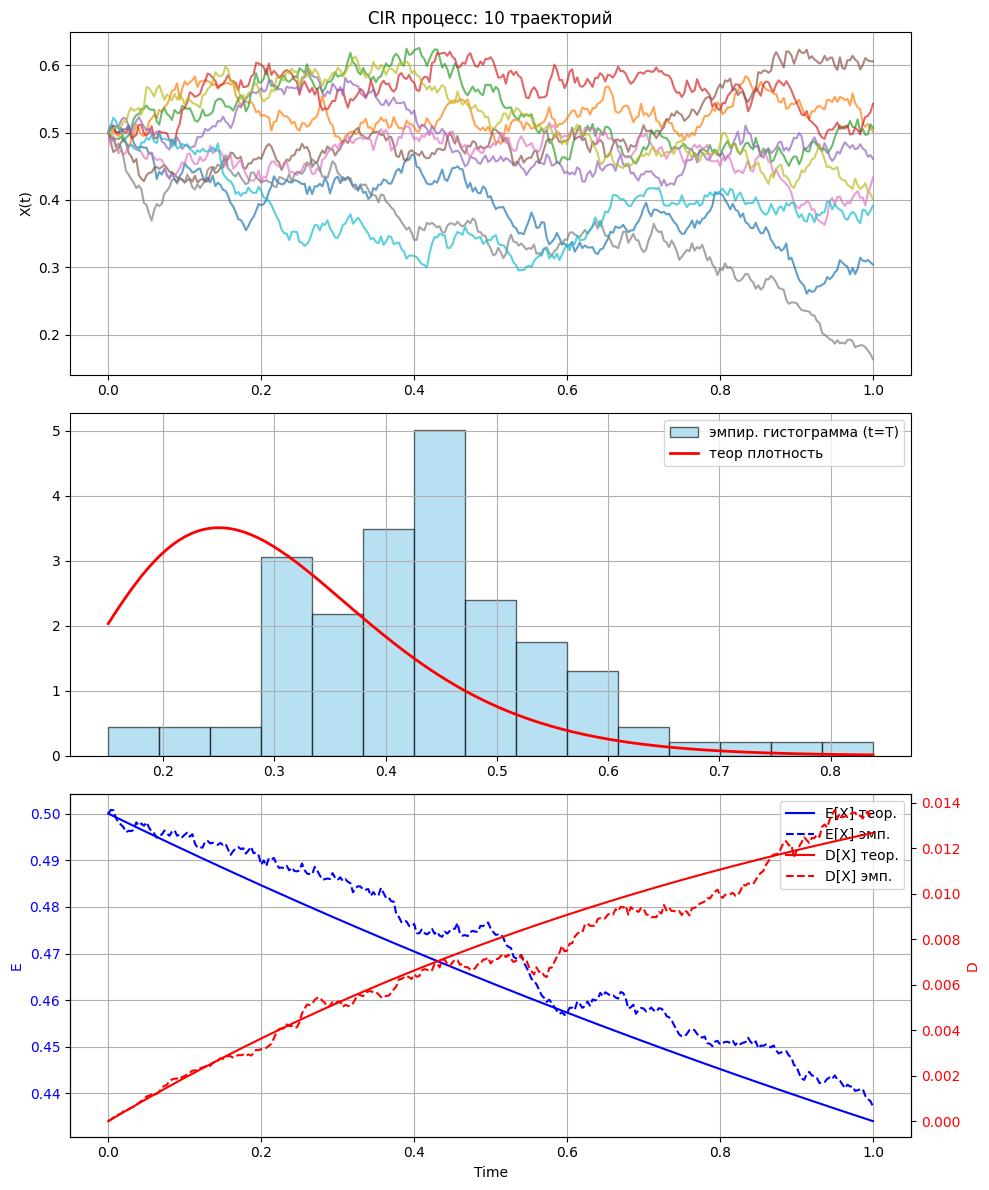

In [22]:
from scipy.stats import norm, gamma, ncx2

def ou_theory(params, x0, t):
    theta, mu, sigma = params
    mean = mu + (x0 - mu) * np.exp(-theta * t)
    var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))
    return mean, var

def cir_theory_mean_var(params, x0, t):
    k, theta, sigma = params
    mean = theta + (x0 - theta) * np.exp(-k * t)
    var = x0 * (sigma**2 / k) * (np.exp(-k * t) - np.exp(-2 * k * t)) + \
          theta * (sigma**2 / (2 * k)) * (1 - np.exp(-k * t))**2
    return mean, var

def cir_stationary_pdf(x, params):
    k, theta, sigma = params
    shape = 2 * k * theta / (sigma**2)
    scale = sigma**2 / (2 * k)
    return gamma.pdf(x, a=shape, scale=scale)

def ou_stationary_pdf(x, params):
    theta, mu, sigma = params
    var_stat = sigma**2 / (2 * theta)
    return norm.pdf(x, loc=mu, scale=np.sqrt(var_stat))

T = 1.0
Nt = 300
Nx = 100
x0 = 0.5
dt = T / Nt
t_vec = np.linspace(0, T, Nt + 1)

params_ou = [1.0, 1.0, 0.5]
params_cir = [0.4, 0.3, 0.2]

np.random.seed(123)

dW_ou = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))
X_ou = np.zeros((Nt + 1, Nx))
X_ou[0] = x0
for i in range(Nt):
    X_ou[i+1] = X_ou[i] + params_ou[0] * (params_ou[1] - X_ou[i]) * dt + params_ou[2] * dW_ou[i]

dW_cir = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))
X_cir = np.zeros((Nt + 1, Nx))
X_cir[0] = x0
for i in range(Nt):
    drift = params_cir[0] * (params_cir[1] - X_cir[i]) * dt
    diff = params_cir[2] * np.sqrt(np.maximum(X_cir[i], 0)) * dW_cir[i]
    X_cir[i+1] = np.maximum(X_cir[i] + drift + diff, 0)

times_check = [0.1, 0.5, 1.0]

for proc_name, X, params in [("OU", X_ou, params_ou), ("CIR", X_cir, params_cir)]:
    print(f"Процесс: {proc_name}")
    print('Time     E_emp    E_theo    Var_emp   Var_theo')
    for t in times_check:
        idx = int(t / dt)
        samples = X[idx, :]

        emp_mean = np.mean(samples)
        emp_var = np.var(samples)

        if proc_name == "OU":
            theo_mean, theo_var = ou_theory(params, x0, t)
        else:
            theo_mean, theo_var = cir_theory_mean_var(params, x0, t)

        print(f"{t:.1f}      {emp_mean:.4f}      {theo_mean:.4f}      {emp_var:.4f}      {theo_var:.4f}")

def plot_panel(process_name, X, t_vec, params, theory_func, stat_pdf_func):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 2, 2]})

    ax1 = axes[0]
    indices_random = np.random.choice(Nx, 10, replace=False)
    for idx in indices_random:
        ax1.plot(t_vec, X[:, idx], alpha=0.7)
    ax1.set_title(f'{process_name} процесс: 10 траекторий')
    ax1.set_ylabel('X(t)')
    ax1.grid(True)

    ax2 = axes[1]
    final_values = X[-1, :]
    ax2.hist(final_values, bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='эмпир. гистограмма (t=T)')

    x_range = np.linspace(min(final_values), max(final_values), 200)
    pdf_vals = stat_pdf_func(x_range, params)
    ax2.plot(x_range, pdf_vals, 'r-', linewidth=2, label='теор плотность')

    ax2.legend()
    ax2.grid(True)

    ax3 = axes[2]
    mean_theo = []
    var_theo = []
    for t in t_vec:
        m, v = theory_func(params, x0, t)
        mean_theo.append(m)
        var_theo.append(v)

    mean_emp = np.mean(X, axis=1)
    var_emp = np.var(X, axis=1)

    ax3_twin = ax3.twinx()

    line1 = ax3.plot(t_vec, mean_theo, 'b-', label='E[X] теор.')
    line2 = ax3.plot(t_vec, mean_emp, 'b--', label='E[X] эмп.')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('E', color='b')
    ax3.tick_params(axis='y', labelcolor='b')

    line3 = ax3_twin.plot(t_vec, var_theo, 'r-', label='D[X] теор.')
    line4 = ax3_twin.plot(t_vec, var_emp, 'r--', label='D[X] эмп.')
    ax3_twin.set_ylabel('D', color='r')
    ax3_twin.tick_params(axis='y', labelcolor='r')


    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='upper right')
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

plot_panel("OU", X_ou, t_vec, params_ou, ou_theory, ou_stationary_pdf)
plot_panel("CIR", X_cir, t_vec, params_cir, cir_theory_mean_var, cir_stationary_pdf)

Реализованные схемы обеспечивают корректное воспроизведение первых двух моментов стохастических процессов. Для более точного попадания в хвосты распределения ( и для оценки рисков) требуется увеличение числа траекторий Nx до нескольких тысяч.